# SGC Baseline — 3-Fold CV + Kaggle Submission

Quick experiment: train the Simple Graph Convolution (SGC) baseline on the brain graph
super-resolution task, evaluate on all 8 metrics, and produce a submission CSV for Kaggle.

In [16]:
import sys
from pathlib import Path

notebook_dir = Path('.').resolve()
repo_root = notebook_dir.parent
sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / 'gcn-encoder-ca-decoder'))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold

from data_utils import vec_to_adj, lr_node_features, to_tensor
from models.sgc_baseline import SGCBaseline
from utils.matrix_vectorizer import MatrixVectorizer
from utils.metrics import evaluate_fold
from utils.plotting import plot_folds

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


## Load Data

In [17]:
def load_csv(path):
    arr = np.loadtxt(path, delimiter=',', skiprows=1, dtype=np.float32)
    return arr if arr.ndim > 1 else arr[None, :]

X_lr_train = load_csv(repo_root / 'data' / 'lr_train.csv')
Y_hr_train = load_csv(repo_root / 'data' / 'hr_train.csv')
X_lr_test  = load_csv(repo_root / 'data' / 'lr_test.csv')

print(f'Train LR: {X_lr_train.shape}')
print(f'Train HR: {Y_hr_train.shape}')
print(f'Test  LR: {X_lr_test.shape}')

Train LR: (167, 12720)
Train HR: (167, 35778)
Test  LR: (112, 12720)


## Config

In [18]:
N_LR, N_HR = 160, 268

MODEL_KWARGS = dict(n_lr=N_LR, n_hr=N_HR, d_model=64, K=2, in_node_feat_dim=2)
EPOCHS = 400
PATIENCE = 30
BATCH_SIZE = 16
LR = 1e-3
WEIGHT_DECAY = 1e-5

print(f'SGC config: {MODEL_KWARGS}')
print(f'Training:   {EPOCHS} epochs (patience={PATIENCE}), bs={BATCH_SIZE}, lr={LR}')

SGC config: {'n_lr': 160, 'n_hr': 268, 'd_model': 64, 'K': 2, 'in_node_feat_dim': 2}
Training:   400 epochs (patience=30), bs=16, lr=0.001


## Training Loop (single fold)

In [19]:
def train_one_fold(X_tr, Y_tr, X_va, Y_va, fold_id):
    Xtr, Ytr = to_tensor(X_tr, DEVICE), to_tensor(Y_tr, DEVICE)
    Xva, Yva = to_tensor(X_va, DEVICE), to_tensor(Y_va, DEVICE)

    tr_loader = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)
    va_loader = DataLoader(TensorDataset(Xva, Yva), batch_size=BATCH_SIZE, shuffle=False)

    model = SGCBaseline(**MODEL_KWARGS).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.MSELoss()

    best_val, best_state = float('inf'), None
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for x_vec, y_vec in tr_loader:
            A = vec_to_adj(x_vec, N_LR)
            X = lr_node_features(A)
            loss = loss_fn(model(A, X), y_vec)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_vec, y_vec in va_loader:
                A = vec_to_adj(x_vec, N_LR)
                X = lr_node_features(A)
                val_losses.append(loss_fn(model(A, X), y_vec).item())

        val_loss = np.mean(val_losses)
        improved = val_loss < best_val
        if improved:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 10 == 0 or epoch == 1:
            mark = ' *' if improved else ''
            print(f'  Fold {fold_id} | Epoch {epoch:3d}/{EPOCHS} | Val: {val_loss:.6f}{mark}')

        if patience_counter >= PATIENCE:
            print(f'  Early stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
            break

    model.load_state_dict(best_state)
    print(f'  Fold {fold_id} best val loss: {best_val:.6f}')
    return model

## 3-Fold Cross-Validation + Metrics

In [20]:
kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
vectorizer = MatrixVectorizer()

fold_metrics = []
fold_models = []

for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_lr_train), start=1):
    print(f"\n{'='*50}")
    print(f'Fold {fold_id}: train={len(tr_idx)}, val={len(va_idx)}')
    print(f"{'='*50}")

    model = train_one_fold(
        X_lr_train[tr_idx], Y_hr_train[tr_idx],
        X_lr_train[va_idx], Y_hr_train[va_idx],
        fold_id,
    )
    fold_models.append(model)

    # Evaluate on validation set
    model.eval()
    va_preds, va_targets = [], []
    va_loader = DataLoader(
        TensorDataset(to_tensor(X_lr_train[va_idx], DEVICE),
                       to_tensor(Y_hr_train[va_idx], DEVICE)),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    with torch.no_grad():
        for x_vec, y_vec in va_loader:
            A = vec_to_adj(x_vec, N_LR)
            X = lr_node_features(A)
            va_preds.append(model(A, X).cpu().numpy())
            va_targets.append(y_vec.cpu().numpy())

    pred_vecs = np.concatenate(va_preds)
    gt_vecs = np.concatenate(va_targets)
    pred_mats = np.stack([vectorizer.anti_vectorize(v, N_HR) for v in pred_vecs])
    gt_mats = np.stack([vectorizer.anti_vectorize(v, N_HR) for v in gt_vecs])

    print(f'\n  Metrics for fold {fold_id}:')
    metrics = evaluate_fold(pred_mats, gt_mats, verbose=True)
    fold_metrics.append(metrics)

print('\n\nAll 3 folds evaluated.')


Fold 1: train=111, val=56


  Fold 1 | Epoch   1/400 | Val: 9.825536 *
  Fold 1 | Epoch  10/400 | Val: 2.160603
  Fold 1 | Epoch  20/400 | Val: 0.925358 *
  Fold 1 | Epoch  30/400 | Val: 0.616253 *
  Fold 1 | Epoch  40/400 | Val: 0.448375 *
  Fold 1 | Epoch  50/400 | Val: 0.339660 *
  Fold 1 | Epoch  60/400 | Val: 0.268755 *
  Fold 1 | Epoch  70/400 | Val: 0.217813 *
  Fold 1 | Epoch  80/400 | Val: 0.183259 *
  Fold 1 | Epoch  90/400 | Val: 0.157951 *
  Fold 1 | Epoch 100/400 | Val: 0.140703 *
  Fold 1 | Epoch 110/400 | Val: 0.128909 *
  Fold 1 | Epoch 120/400 | Val: 0.120839 *
  Fold 1 | Epoch 130/400 | Val: 0.114838 *
  Fold 1 | Epoch 140/400 | Val: 0.111054 *
  Fold 1 | Epoch 150/400 | Val: 0.108686 *
  Fold 1 | Epoch 160/400 | Val: 0.106685 *
  Fold 1 | Epoch 170/400 | Val: 0.105279 *
  Fold 1 | Epoch 180/400 | Val: 0.104251 *
  Fold 1 | Epoch 190/400 | Val: 0.103341 *
  Fold 1 | Epoch 200/400 | Val: 0.102592 *
  Fold 1 | Epoch 210/400 | Val: 0.102079 *
  Fold 1 | Epoch 220/400 | Val: 0.101381 *
  Fold 1 | Ep

## Bar Plots

Plotting 3 fold(s).
Scale ratio (max/min over finite values): 126465.267


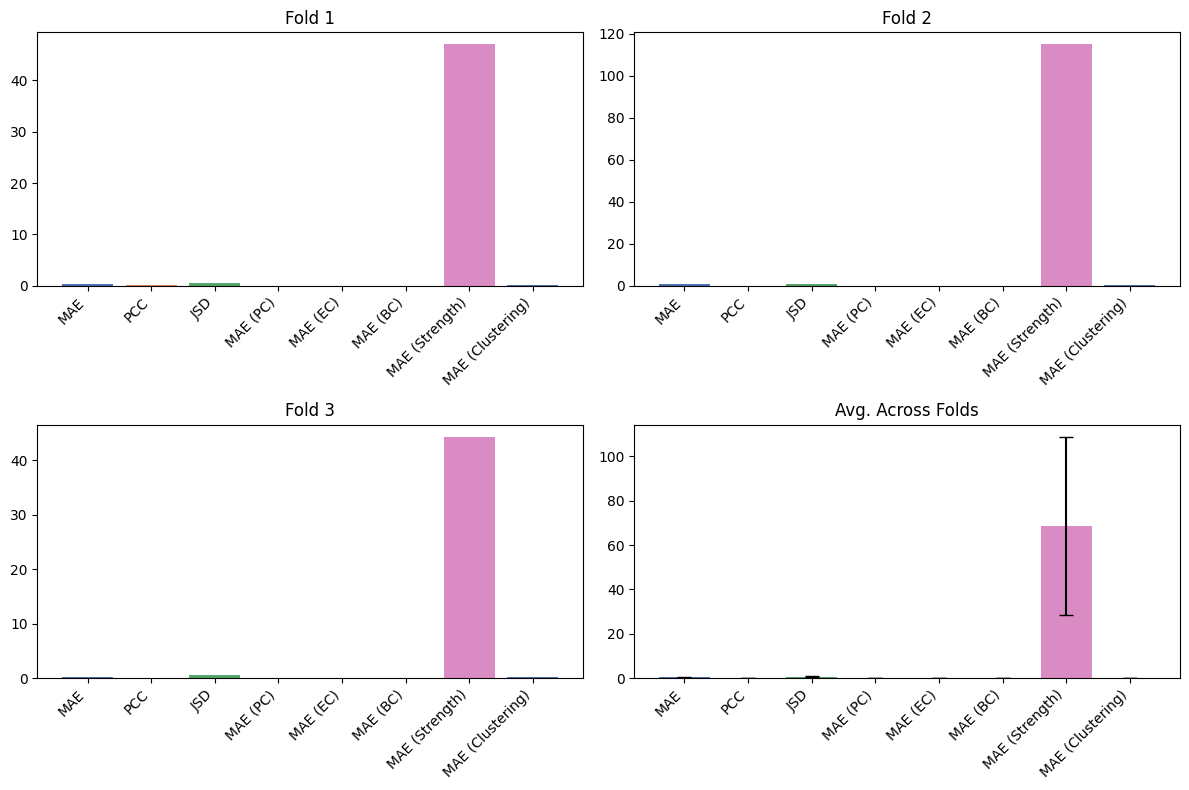

In [21]:
plot_folds(fold_metrics)

## Generate Kaggle Submission (ensemble of 3 folds)

In [22]:
test_preds = []
for i, model in enumerate(fold_models):
    model.eval()
    loader = DataLoader(
        TensorDataset(to_tensor(X_lr_test, DEVICE)),
        batch_size=BATCH_SIZE, shuffle=False,
    )
    preds = []
    with torch.no_grad():
        for (x_vec,) in loader:
            A = vec_to_adj(x_vec, N_LR)
            X = lr_node_features(A)
            preds.append(model(A, X).cpu().numpy())
    test_preds.append(np.concatenate(preds))
    print(f'Fold {i+1} test predictions: {test_preds[-1].shape}')

ensemble = np.clip(np.mean(test_preds, axis=0), a_min=0.0, a_max=None)
print(f'\nEnsemble shape: {ensemble.shape}')
print(f'Range: [{ensemble.min():.6f}, {ensemble.max():.6f}]')

Fold 1 test predictions: (112, 35778)
Fold 2 test predictions: (112, 35778)
Fold 3 test predictions: (112, 35778)

Ensemble shape: (112, 35778)
Range: [0.000000, 91.510002]


In [23]:
import pandas as pd

n_subjects, n_features = ensemble.shape
ids = np.arange(1, n_subjects * n_features + 1)
submission = pd.DataFrame({'ID': ids, 'Predicted': ensemble.flatten()})

sub_dir = repo_root / 'submission'
sub_dir.mkdir(exist_ok=True)

counter = 1
out_path = sub_dir / f'sgc_submission_{counter}.csv'
while out_path.exists():
    counter += 1
    out_path = sub_dir / f'sgc_submission_{counter}.csv'

submission.to_csv(out_path, index=False)

print(f'Saved to {out_path} ({len(submission):,} rows)')
print(submission.head())

Saved to /home/jeet/y4/neurores-gnn/submission/sgc_submission_1.csv (4,007,136 rows)
   ID  Predicted
0   1   0.020171
1   2   0.000000
2   3   0.010783
3   4   0.037588
4   5   0.041107
